### Sara Albrecht, Gesa Röefzaad, Tim Paetsch, Caroline Roschek
---

# Exploratory Data Analysis

Use of AI tools: OpenAI ChatGPT/Claude was used throughout the project to assist with debugging, code optimization, and the creation of data visualizations.

## Configuration

In [25]:
import os 
import json 
from pathlib import Path

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

base_dir = "data"
train_dir = os.path.join(base_dir, "train")
train_meta_path = os.path.join(base_dir, "train.csv")

results_dir = "results"
output_dir = os.path.join(results_dir, "outputs")
eda_output_dir = os.path.join(results_dir, "eda_figures")

os.makedirs(eda_output_dir, exist_ok=True)

# split-aware EDA (train/val/test breakdowns)
split_path = os.path.join(output_dir, "baseline_split.csv")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Metadata path:", train_meta_path)
print("Image directory:", train_dir)
print("Split file:", split_path, "| exists:", os.path.exists(split_path))

Metadata path: data\train.csv
Image directory: data\train
Split file: results\outputs\baseline_split.csv | exists: True


## Load Data

In [26]:
# Load raw metadata
train_meta = pd.read_csv(train_meta_path)

required_columns = {"image_id", "class_id", "class_name"}
missing_columns = required_columns - set(train_meta.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

train_meta["class_id"] = train_meta["class_id"].astype(int)

# Class table (all 15 original classes, including "No finding")
full_class_table = (
    train_meta[["class_id", "class_name"]]
    .drop_duplicates()
    .sort_values("class_id")
    .reset_index(drop=True)
)

no_finding_matches = full_class_table[full_class_table["class_name"].str.strip().str.lower().eq("no finding")]
if len(no_finding_matches) != 1:
    raise ValueError("The class 'No finding' could not be identified uniquely")
NO_FINDING_ID = int(no_finding_matches.iloc[0]["class_id"])

# 14 pathological classes only (for modeling-aligned label matrices)
class_table = (
    full_class_table[full_class_table["class_id"] != NO_FINDING_ID]
    .sort_values("class_id")
    .reset_index(drop=True)
)
class_names = class_table["class_name"].tolist()
NUM_CLASSES = len(class_table)

class_id_to_index = {
    int(original_class_id): model_index
    for model_index, original_class_id in enumerate(class_table["class_id"])
}

# Build per-image label sets
image_labels = {}
for image_id, group in train_meta.groupby("image_id", sort=False):
    original_labels = set(group["class_id"].astype(int))
    original_labels.discard(NO_FINDING_ID)
    disease_labels = {class_id_to_index[c] for c in original_labels if c in class_id_to_index}
    image_labels[image_id] = disease_labels

image_ids = sorted(image_labels)

def build_label_matrix(image_id_list, labels_by_image, num_classes):
    matrix = np.zeros((len(image_id_list), num_classes), dtype=np.float32)
    for row_index, img_id in enumerate(image_id_list):
        for class_id in labels_by_image[img_id]:
            matrix[row_index, class_id] = 1.0
    return matrix

full_label_matrix = build_label_matrix(image_ids, image_labels, NUM_CLASSES)

# Resolve image file paths once (mirrors AMIADataset's approach, avoids repeated glob calls)
image_dir = Path(train_dir)
image_paths = {}
for image_id in image_ids:
    candidates = sorted(image_dir.glob(f"{image_id}.*"))
    if candidates:
        image_paths[image_id] = candidates[0]

missing_files = [img_id for img_id in image_ids if img_id not in image_paths]
if missing_files:
    print(f"Warning: {len(missing_files)} image_ids have no matching file on disk (of {len(image_ids)} total)")

# load the existing train/val/test split for split-aware EDA
if os.path.exists(split_path):
    split_table = pd.read_csv(split_path)
    train_ids = split_table.loc[split_table["split"] == "train", "image_id"].tolist()
    val_ids = split_table.loc[split_table["split"] == "validation", "image_id"].tolist()
    test_ids = split_table.loc[split_table["split"] == "test", "image_id"].tolist()

    train_label_matrix = build_label_matrix(train_ids, image_labels, NUM_CLASSES)
    val_label_matrix = build_label_matrix(val_ids, image_labels, NUM_CLASSES)
    test_label_matrix = build_label_matrix(test_ids, image_labels, NUM_CLASSES)

    print("Loaded existing split — Train:", len(train_ids), "| Val:", len(val_ids), "| Test:", len(test_ids))
else:
    train_ids = val_ids = test_ids = None
    train_label_matrix = val_label_matrix = test_label_matrix = None
    print("No split file found — split-aware EDA cells will be skipped. Full-dataset EDA still works.")

print("\nTotal unique images:", len(image_ids))
print("Total annotation rows:", len(train_meta))
print("Pathological classes:", NUM_CLASSES)
print("No-finding images (all-zero label vector):", int((full_label_matrix.sum(axis=1) == 0).sum()))

Loaded existing split — Train: 6001 | Val: 1286 | Test: 1286

Total unique images: 8573
Total annotation rows: 45925
Pathological classes: 14
No-finding images (all-zero label vector): 5175


In [27]:
if train_label_matrix is not None:
    distribution_table = pd.DataFrame({
        "class_id": range(NUM_CLASSES),
        "class_name": class_names,

        "train_positive": train_label_matrix.sum(axis=0).astype(int),
        "validation_positive": val_label_matrix.sum(axis=0).astype(int),
        "test_positive": test_label_matrix.sum(axis=0).astype(int),

        "train_prevalence": train_label_matrix.mean(axis=0),
        "validation_prevalence": val_label_matrix.mean(axis=0),
        "test_prevalence": test_label_matrix.mean(axis=0),
    })
else:
    # No split file available — fall back to full-dataset prevalence only
    distribution_table = pd.DataFrame({
        "class_id": range(NUM_CLASSES),
        "class_name": class_names,
        "total_positive": full_label_matrix.sum(axis=0).astype(int),
        "total_prevalence": full_label_matrix.mean(axis=0),
    })

display(distribution_table)

,class_id,class_name,train_positive,validation_positive,test_positive,train_prevalence,validation_prevalence,test_prevalence
0,0,Aortic enlargement,1649,360,356,0.274788,0.279938,0.276827
1,1,Atelectasis,121,23,23,0.020163,0.017885,0.017885
2,2,Calcification,266,65,54,0.044326,0.050544,0.041991
3,3,Cardiomegaly,1218,266,262,0.202966,0.206843,0.203733
4,4,Consolidation,229,43,53,0.038160,0.033437,0.041213
5,5,ILD,237,54,50,0.039493,0.041991,0.038880
6,6,Infiltration,377,74,81,0.062823,0.057543,0.062986
7,7,Lung Opacity,793,169,170,0.132145,0.131415,0.132193
8,8,Nodule/Mass,498,99,108,0.082986,0.076983,0.083981
9,9,Other lesion,677,140,148,0.112815,0.108865,0.115086


In [28]:
import torch
from torch.utils.data import Dataset

class AMIADataset(Dataset):
    def __init__(self, image_ids, image_dir, image_labels, num_classes, transform=None):
        self.image_ids = list(image_ids)
        self.image_dir = Path(image_dir)
        self.image_labels = image_labels
        self.num_classes = num_classes
        self.transform = transform

        self.image_paths = {}
        for image_id in self.image_ids:
            candidates = sorted(self.image_dir.glob(f"{image_id}.*"))
            if not candidates:
                raise FileNotFoundError(f"No image file found for image_id={image_id} in {self.image_dir}")
            self.image_paths[image_id] = candidates[0]

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = Image.open(self.image_paths[image_id]).convert("L")

        labels = np.zeros(self.num_classes, dtype=np.float32)
        for class_id in self.image_labels[image_id]:
            labels[class_id] = 1.0

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.from_numpy(labels)


# train_ids if a split exists, else all images
dataset_ids = train_ids if train_ids is not None else image_ids

train_dataset = AMIADataset(
    image_ids=dataset_ids,
    image_dir=train_dir,
    image_labels=image_labels,
    num_classes=NUM_CLASSES,
    transform=None,  # no transform needed for EDA 
)

print("EDA dataset size:", len(train_dataset))

EDA dataset size: 6001


## Class Prevalence & Co-Occurrence

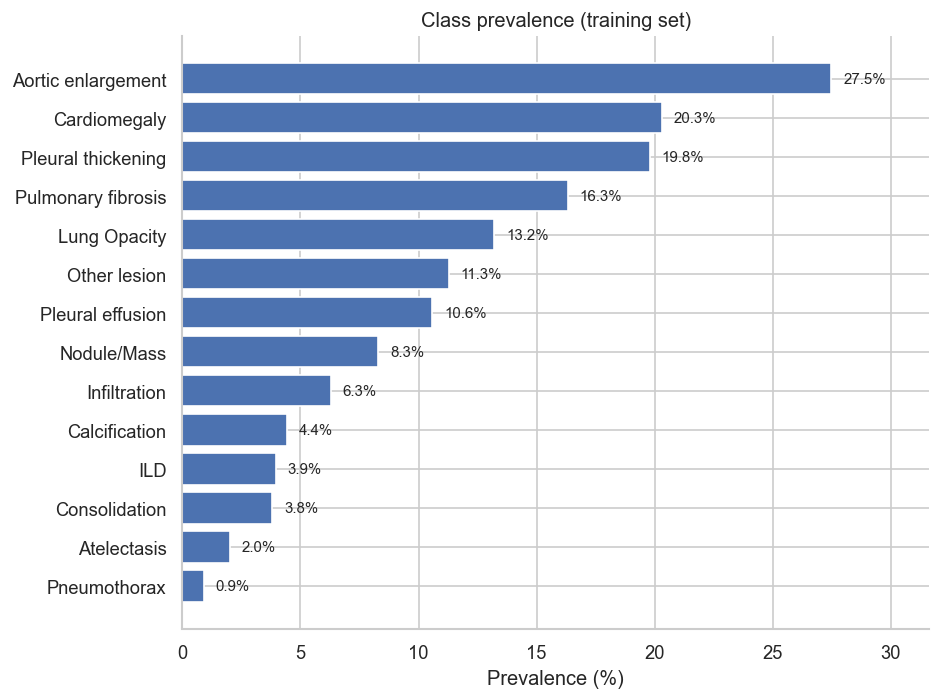

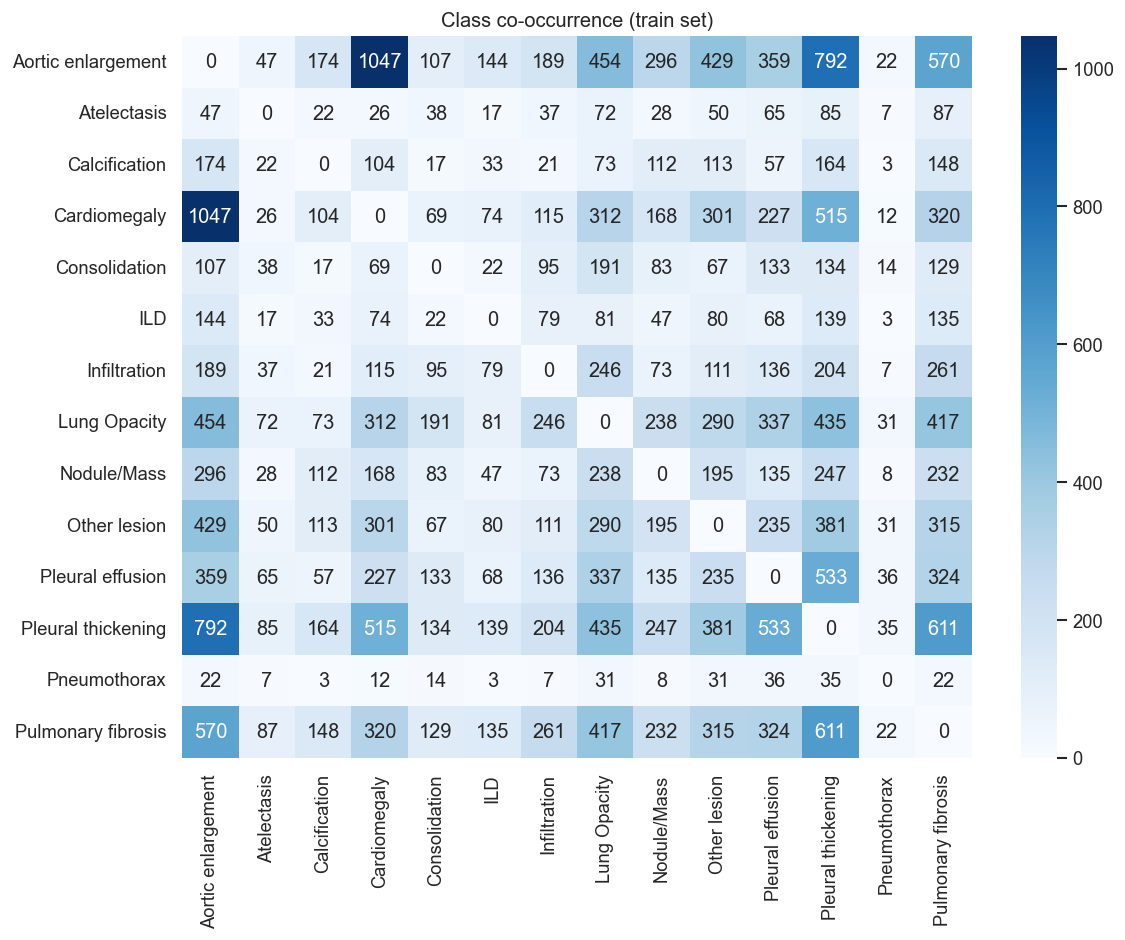

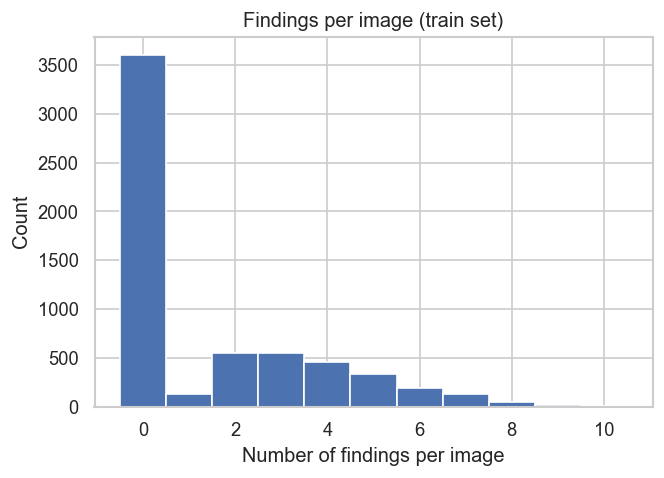

In [ ]:
# Class prevalence Bar Chart (based on distribution_table)
if "train_prevalence" in distribution_table.columns:
    prevalence_col = "train_prevalence"
    subtitle = "(training set)"
else:
    prevalence_col = "total_prevalence"
    subtitle = "(full dataset)"

plot_df = distribution_table[["class_name", prevalence_col]].copy()
plot_df = plot_df.sort_values(prevalence_col, ascending=True) 

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(plot_df["class_name"], plot_df[prevalence_col] * 100, color="#4C72B0")

for bar, value in zip(bars, plot_df[prevalence_col] * 100):
    ax.text(
        value + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%", va="center", fontsize=9
    )

ax.set_xlabel("Prevalence (%)")
ax.set_title(f"Class prevalence {subtitle}")
ax.set_xlim(0, plot_df[prevalence_col].max() * 100 * 1.15) 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{eda_output_dir}/class_prevalence.png")
plt.show()

# Co-occurrence matrix
cooccurrence = train_label_matrix.T @ train_label_matrix  # (14, 14)
np.fill_diagonal(cooccurrence, 0)  # zero out diagonal (self-co-occurrence)

plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence, xticklabels=class_names, yticklabels=class_names, annot=True, fmt=".0f", cmap="Blues")
plt.title("Class co-occurrence (train set)")
plt.tight_layout()
plt.savefig(f"{eda_output_dir}/class_co-occurence.png")
plt.show()

# Labels-per-image histogram
labels_per_image = train_label_matrix.sum(axis=1)
plt.figure(figsize=(6, 4))
plt.hist(labels_per_image, bins=np.arange(0, labels_per_image.max() + 2) - 0.5)
plt.xlabel("Number of findings per image")
plt.ylabel("Count")
plt.title("Findings per image (train set)")
plt.savefig(f"{eda_output_dir}/num_findings_image.png")
plt.show()

In [35]:
labels_per_image = labels_per_image.astype(int)

# Exact counts per number of findings
counts = np.bincount(labels_per_image)

for n_findings, count in enumerate(counts):
    print(f"{n_findings} findings: {count} images")

0 findings: 3610 images
1 findings: 124 images
2 findings: 545 images
3 findings: 553 images
4 findings: 453 images
5 findings: 336 images
6 findings: 190 images
7 findings: 124 images
8 findings: 50 images
9 findings: 12 images
10 findings: 4 images


## Annotator disagreement 

In [30]:
# Annotator disagreement: images where different rows disagree on presence of "No finding"
disagreement_count = 0
for image_id, group in train_meta.groupby("image_id", sort=False):
    labels_present = set(group["class_id"].astype(int))
    has_no_finding = NO_FINDING_ID in labels_present
    has_disease = len(labels_present - {NO_FINDING_ID}) > 0
    if has_no_finding and has_disease:
        disagreement_count += 1

print(f"Images with 'No finding' + a disease label simultaneously: {disagreement_count} "
      f"({disagreement_count / len(image_ids) * 100:.1f}%)")

Images with 'No finding' + a disease label simultaneously: 0 (0.0%)


## Image Properties

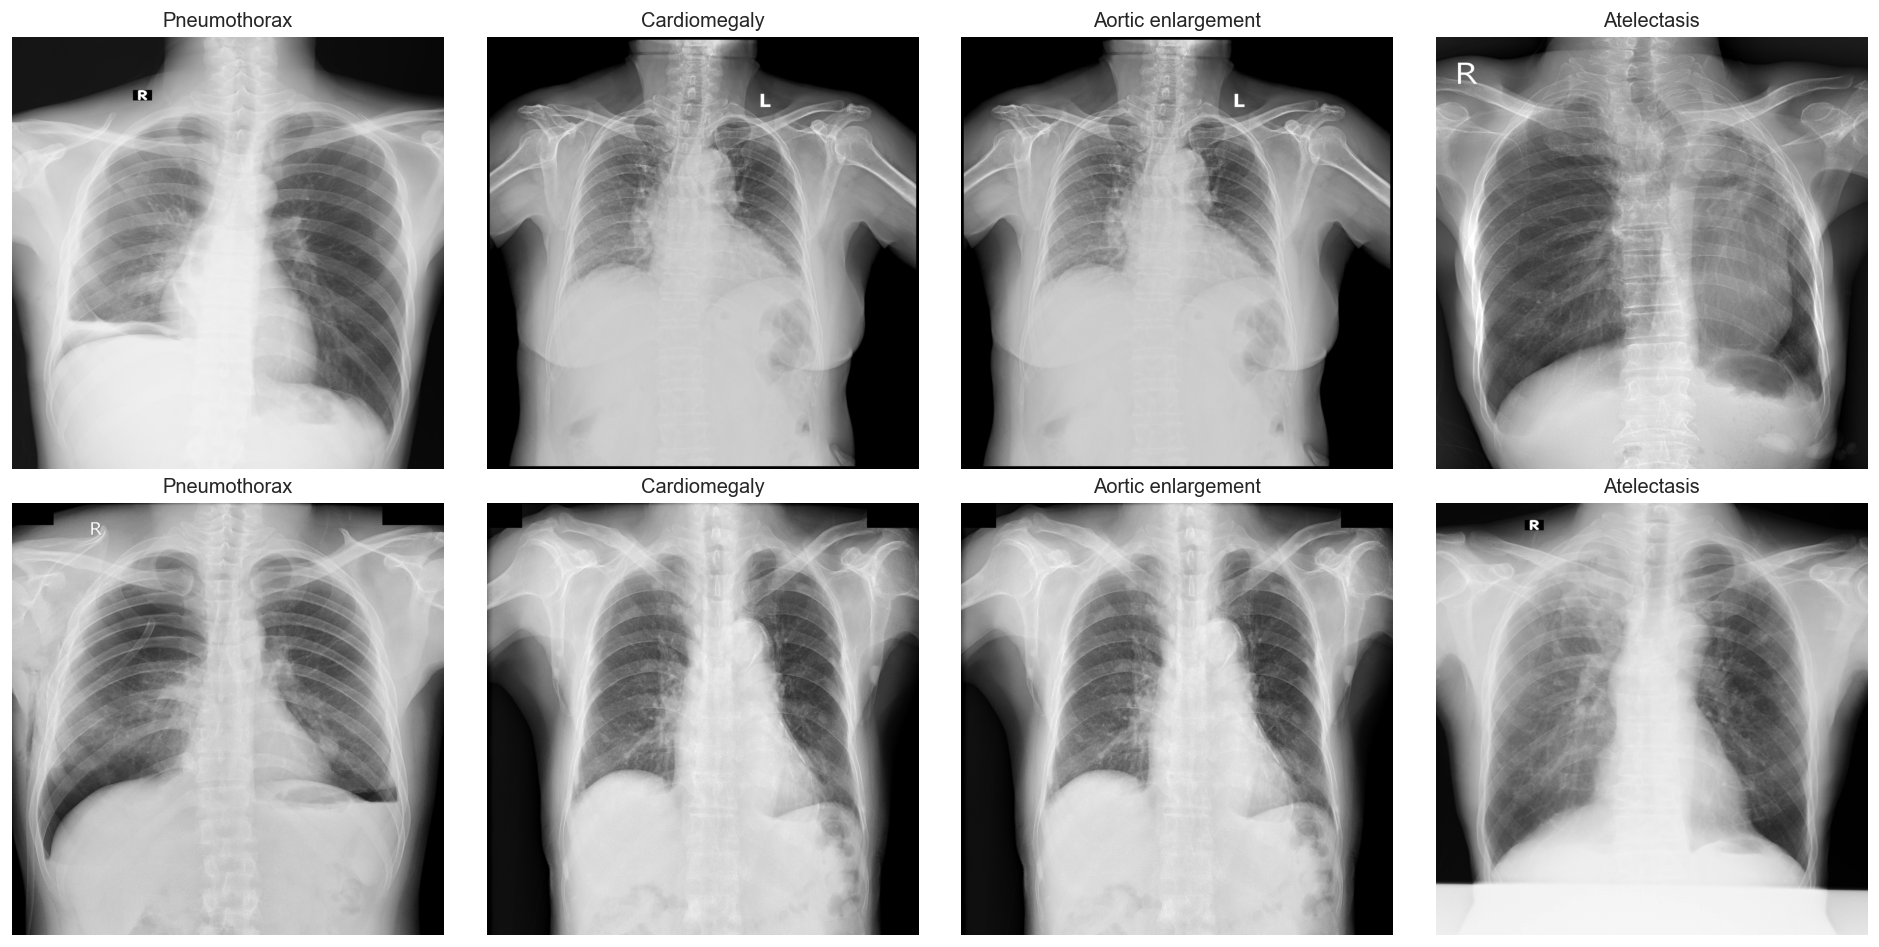

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = ["Pneumothorax", "Cardiomegaly", "Aortic enlargement", "Atelectasis"]

for col, cls in enumerate(sample_classes):
    cls_idx = class_names.index(cls)
    example_ids = [img_id for img_id in train_ids if cls_idx in image_labels[img_id]][:2]
    for row, img_id in enumerate(example_ids):
        img = Image.open(train_dataset.image_paths[img_id]).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{cls}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(f"{eda_output_dir}/example_images_per_class.png", dpi=150)
plt.show()

## Split validation

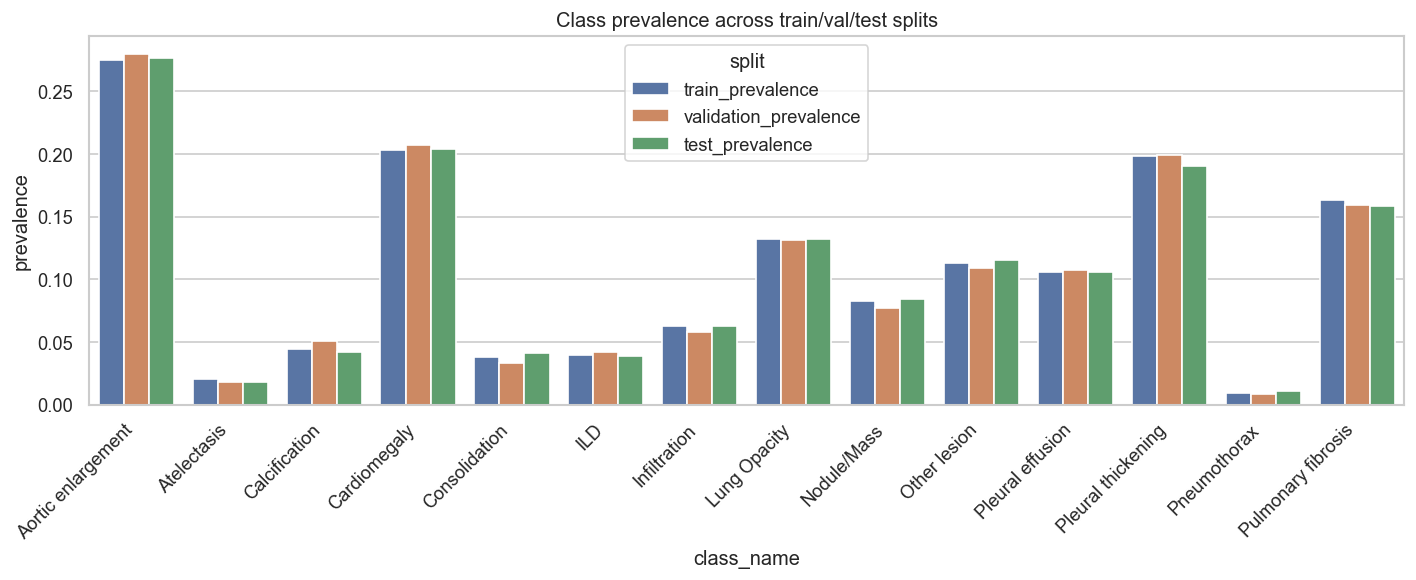

In [32]:
plot_data = distribution_table.melt(
    id_vars="class_name",
    value_vars=["train_prevalence", "validation_prevalence", "test_prevalence"],
    var_name="split", value_name="prevalence"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x="class_name", y="prevalence", hue="split")
plt.xticks(rotation=45, ha="right")
plt.title("Class prevalence across train/v" \
"al/test splits")
plt.tight_layout()
plt.savefig(f"{eda_output_dir}/class_prevalence_split.png")
plt.show()